In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [29]:
df=pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [30]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [32]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [36]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

In [37]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [38]:
df.shape

(10000, 11)

In [39]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [40]:
df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [41]:
df.nunique()

CreditScore         460
Geography             3
Gender                2
Age                  70
Tenure               11
Balance            6382
NumOfProducts         4
HasCrCard             2
IsActiveMember        2
EstimatedSalary    9999
Exited                2
dtype: int64

In [42]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True).astype(int)

In [45]:
X= df.drop(columns=['Exited'])
y= df['Exited'].values
from sklearn.model_selection import train_test_split
X_train, X_test, y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 0)





In [49]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)


In [54]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

model.add(Input(shape=(11,)))
model.add(Dense(11, activation='sigmoid'))
model.add(Dense(11, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

In [57]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [60]:
history = model.fit(X_train_trf, y_train,batch_size=50, epochs = 100 , validation_split= 0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5661 - loss: 0.6610 - val_accuracy: 0.7969 - val_loss: 0.5076
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7990 - loss: 0.4949 - val_accuracy: 0.7969 - val_loss: 0.4849
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8018 - loss: 0.4741 - val_accuracy: 0.7969 - val_loss: 0.4739
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7891 - loss: 0.4783 - val_accuracy: 0.7969 - val_loss: 0.4630
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8128 - loss: 0.4382 - val_accuracy: 0.7969 - val_loss: 0.4532
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7970 - loss: 0.4475 - val_accuracy: 0.7969 - val_loss: 0.4447
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7951 - loss: 0.4429 - val_accuracy: 0.7975 - val_loss: 0.4389
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8026 - loss: 0.4320 - val_accu

In [61]:
model.layers[0].get_weights()

[array([[-1.04671471e-01,  1.47597745e-01, -1.60960734e-01,
          1.99150041e-01,  7.56414607e-02,  8.10009763e-02,
          2.33892694e-01,  3.73758793e-01, -1.60357147e-01,
         -3.12440414e-02, -2.55612910e-01],
        [ 1.01884282e+00, -3.65796626e-01,  1.52884368e-02,
          1.18099622e-01,  2.95610338e-01,  1.39155790e-01,
         -2.05316591e+00, -1.49266350e+00,  2.16730261e+00,
         -1.15493787e-02, -1.67244673e+00],
        [ 1.40010387e-01, -1.24465683e-02,  7.15973824e-02,
         -2.46126458e-01,  9.38064083e-02, -1.11243173e-01,
         -2.21591681e-01, -2.73069829e-01, -2.86298215e-01,
         -1.65640607e-01,  1.28048345e-01],
        [ 3.65915626e-01,  1.06124902e+00, -7.17867255e-01,
         -3.67341250e-01, -3.24852645e-01,  5.84154963e-01,
          1.10186584e-01,  5.03077090e-01, -4.49532747e-01,
          6.69764578e-01, -2.86255449e-01],
        [ 3.59664965e+00,  1.61755395e+00, -3.87348562e-01,
         -5.69907546e-01, -4.23165448e-02, -

In [62]:
model.layers[1].get_weights()

[array([[-2.2051978 ,  1.6323051 ,  1.0973668 ,  1.4467264 , -0.93781   ,
         -1.6673303 ,  1.2529073 , -2.1129925 ,  1.1386591 , -0.9607407 ,
         -0.9919636 ],
        [ 1.174765  , -1.3068852 , -1.674814  , -1.2516524 ,  2.0720005 ,
          2.123713  , -1.8508406 ,  1.6761647 , -1.4843855 ,  1.8690832 ,
          1.949568  ],
        [ 0.36692622,  0.32284302,  0.5617725 ,  0.3445466 , -0.20383981,
         -0.3174631 ,  0.44245893,  0.16886955,  0.6324123 , -0.21706004,
         -0.43031102],
        [-0.06257264, -0.19164678,  0.03096879,  0.2173489 ,  0.18742332,
          0.03988282,  0.53927344,  0.17437407,  0.6212439 , -0.6135373 ,
         -0.74816686],
        [-0.5007677 ,  0.20170592,  0.92773086,  0.65349656, -0.6671769 ,
         -0.04779643,  0.06426059, -0.545855  ,  0.73666245, -0.7206559 ,
         -0.03044513],
        [-0.1425363 ,  0.12938026,  0.33309224,  0.272309  , -0.76390475,
         -0.1480571 ,  0.5633087 , -0.48931667, -0.00348018, -0.8131285

In [63]:
model.layers[2].get_weights()

[array([[ 1.2056466],
        [-1.1971338],
        [-1.4156679],
        [-1.2556069],
        [ 0.979612 ],
        [ 1.671356 ],
        [-1.3845916],
        [ 1.9965715],
        [-0.9463538],
        [ 1.5781565],
        [ 1.4519566]], dtype=float32),
 array([-0.13470247], dtype=float32)]

In [64]:
y_log = model.predict(X_test_trf)

y_pred = np.where(y_log> 0.5,1,0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [67]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8585

In [68]:
import matplotlib as plt 

In [69]:
 
history.history 

{'accuracy': [0.7143750190734863,
  0.7957812547683716,
  0.7957812547683716,
  0.7957812547683716,
  0.7957812547683716,
  0.7957812547683716,
  0.7965624928474426,
  0.8035937547683716,
  0.8098437786102295,
  0.8134375214576721,
  0.8151562213897705,
  0.8165624737739563,
  0.81640625,
  0.8181250095367432,
  0.8173437714576721,
  0.8196874856948853,
  0.8201562762260437,
  0.821093738079071,
  0.8220312595367432,
  0.8228124976158142,
  0.8237500190734863,
  0.8270312547683716,
  0.8271874785423279,
  0.8274999856948853,
  0.828906238079071,
  0.8298437595367432,
  0.8310937285423279,
  0.8317187428474426,
  0.831250011920929,
  0.83203125,
  0.8315625190734863,
  0.8354687690734863,
  0.8334375023841858,
  0.8343750238418579,
  0.8339062333106995,
  0.8334375023841858,
  0.8337500095367432,
  0.8362500071525574,
  0.835156261920929,
  0.8357812762260437,
  0.8379687666893005,
  0.8385937213897705,
  0.8393750190734863,
  0.839062511920929,
  0.8415625095367432,
  0.840468764305114

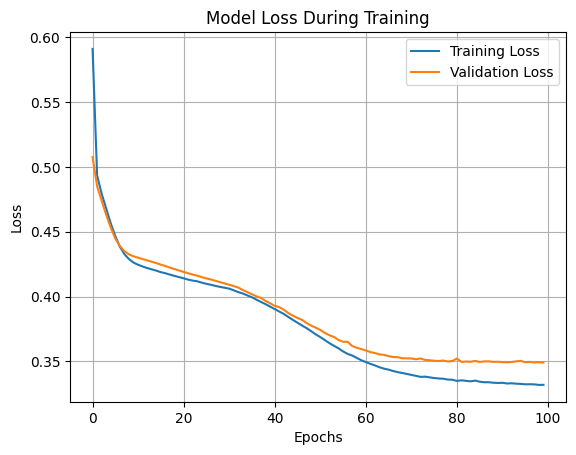

In [71]:


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

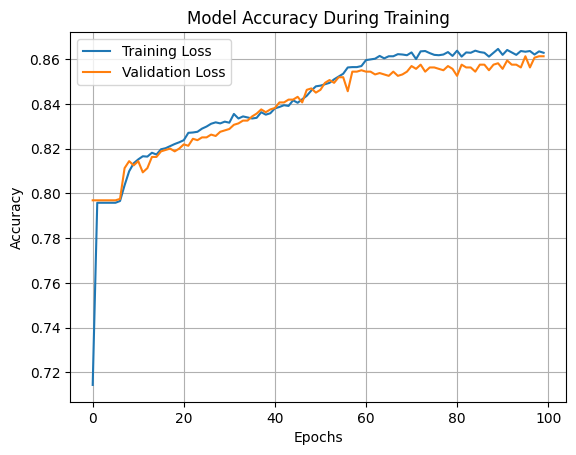

In [73]:


plt.plot(history.history['accuracy'], label='Training Loss')
plt.plot(history.history['val_accuracy'], label='Validation Loss')

plt.title('Model Accuracy During Training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()